# NB 12 — Semi-synthetic Validation: Learned $S_t$ vs Analytical $S_t$

## Protocol

1. Generate trajectories from **Saddle-Node** + **Ecosystem** (seeds 0–14)
2. Train encoder+dynamics on seeds 0–7 (pretend ODE is unknown)
3. Compute $S_t^{\text{learned}}$ on seeds 10–14 (test set)
4. Compute $S_t^{\text{analytical}}$ on the same seeds (ground truth)
5. Compare: $\rho(S_{\text{learned}}, S_{\text{analytical}})$, MSE, Monotonicity

This validates that the learned pipeline recovers basin access probability **without access to the true dynamics**.

### Architecture

```
x_{t-W:t} -> [LSTMEncoder] -> z_t -> [ResidualDynamics]^H -> z_{t+H}
                                   -> [Decoder] -> x_hat_t
```

### Success Criterion

$\rho(S_{\text{learned}}, S_{\text{analytical}}) > 0.80$ on test seeds.

In [1]:
import sys, os
import warnings
warnings.filterwarnings("ignore")

# Project root
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from src.hsp.training import (
    HSPLearnedPipeline,
    HSPTrainer,
)
from src.hsp.survival import DecoderSurvivalFn
from src.hsp.basin_access import BasinAccessConfig, compute_basin_access_learned

print("NB 12 — Semi-synthetic Validation")
print("Imports OK, torch version:", torch.__version__)

NB 12 — Semi-synthetic Validation
Imports OK, torch version: 2.10.0+cpu


---
## 1. System Definitions

Same ODE systems as NB 11, used here as data generators.

In [2]:
# ── Saddle-Node ────────────────────────────────────────────
def saddle_node(T=300, seed=42):
    rng = np.random.RandomState(seed)
    dt, noise = 0.02, 0.08
    r = np.linspace(2.0, -0.5, T)
    x = np.zeros(T)
    x[0] = np.sqrt(r[0])
    for t in range(1, T):
        x[t] = x[t - 1] + dt * (r[t - 1] - x[t - 1] ** 2) + rng.normal(0, noise)
        x[t] = max(x[t], -5.0)
    bif_t = np.argmin(np.abs(r))
    return x, r, bif_t


def rollout_sn(x0, r_start, r_end, N, H, eps=0.05, seed=0):
    rng = np.random.RandomState(seed)
    dt, noise = 0.02, 0.08
    r_vals = np.linspace(r_start, r_end, H)
    x = np.full(N, float(x0)) + rng.normal(0, eps, N)
    futures = np.zeros((N, H))
    for h in range(H):
        x = x + dt * (r_vals[h] - x**2) + rng.normal(0, noise, N)
        x = np.clip(x, -5.0, 5.0)
        futures[:, h] = x
    return futures


def sn_basin_width(r_val):
    return 2.0 * np.sqrt(max(r_val, 0.0))


# ── Ecosystem ──────────────────────────────────────────────
def ecosystem_shift(T=400, seed=42):
    rng = np.random.RandomState(seed)
    dt, noise, r_g, K, s = 0.05, 0.02, 1.0, 1.0, 0.2
    h = np.linspace(0.05, 0.35, T)
    x = np.zeros(T)
    x[0] = 0.8
    for t in range(1, T):
        grazing = h[t - 1] * x[t - 1] ** 2 / (x[t - 1] ** 2 + s**2)
        growth = r_g * x[t - 1] * (1.0 - x[t - 1] / K)
        x[t] = x[t - 1] + dt * (growth - grazing) + rng.normal(0, noise)
        x[t] = max(x[t], 0.01)
    bif_t = T
    for t in range(50, T):
        if x[t] < 0.3:
            bif_t = t
            break
    return x, h, bif_t


def rollout_eco(x0, h_start, h_end, N, H, eps=0.05, seed=0):
    rng = np.random.RandomState(seed)
    dt, noise, r_g, K, s = 0.05, 0.02, 1.0, 1.0, 0.2
    h_vals = np.linspace(h_start, h_end, H)
    x = np.full(N, float(x0)) + rng.normal(0, eps, N)
    x = np.clip(x, 0.01, 3.0)
    futures = np.zeros((N, H))
    for h_step in range(H):
        grazing = h_vals[h_step] * x**2 / (x**2 + s**2)
        growth = r_g * x * (1.0 - x / K)
        x = x + dt * (growth - grazing) + rng.normal(0, noise, N)
        x = np.clip(x, 0.01, 3.0)
        futures[:, h_step] = x
    return futures


def eco_basin_width(h_val, r_g=1.0, K=1.0, s=0.2):
    coeffs = [1, -1, s**2 + h_val, -(s**2)]
    roots = np.roots(coeffs)
    real_pos = sorted([rt.real for rt in roots if abs(rt.imag) < 1e-8 and rt.real > 0.01])
    if len(real_pos) >= 2:
        return real_pos[-1] - real_pos[-2]
    elif len(real_pos) == 1:
        return real_pos[0]
    return 0.0


print("Systems defined.")

Systems defined.


---
## 2. Constants & Registry

In [3]:
# ── HSP parameters ────────────────────────────────────────
N_ROLLOUTS  = 300
HORIZON     = 15
STEP        = 5
EWS_WINDOW  = 25

# Per-system perturbation
PERTURB_STD_SN  = 0.4    # SN range ~2.4, sigma ~17%
PERTURB_STD_ECO = 0.15   # Eco range ~0.8, sigma ~19%
PERTURB_TAIL    = 8      # Perturb last 8 of 25 window steps

# ── Train / Val / Test splits ─────────────────────────────
TRAIN_SEEDS = list(range(8))
VAL_SEEDS   = [8, 9]
TEST_SEEDS  = list(range(10, 15))

# ── Model config ─────────────────────────────────────────
LATENT_DIM   = 8
HIDDEN_DIM   = 64
WINDOW_SIZE  = 25
PREDICTION_K = 20
EPOCHS       = 500
BATCH_SIZE   = 64
LR           = 1e-3
PATIENCE     = 50

# ── System registry ──────────────────────────────────────
SYSTEMS = [
    {
        "name": "Saddle-Node",
        "gen": saddle_node,
        "roll": rollout_sn,
        "thresh": -0.5,
        "surv_dir": "above",
        "basin_fn": sn_basin_width,
        "T": 300,
        "perturb_std": PERTURB_STD_SN,
    },
    {
        "name": "Ecosystem",
        "gen": ecosystem_shift,
        "roll": rollout_eco,
        "thresh": 0.3,
        "surv_dir": "above",
        "basin_fn": eco_basin_width,
        "T": 400,
        "perturb_std": PERTURB_STD_ECO,
    },
]

# ── Output dir ────────────────────────────────────────────
OUT_DIR = os.path.join("..", "results", "semisynthetic")
os.makedirs(OUT_DIR, exist_ok=True)

print(f"Systems: {[s['name'] for s in SYSTEMS]}")
print(f"Train seeds: {TRAIN_SEEDS}, Val: {VAL_SEEDS}, Test: {TEST_SEEDS}")
print(f"Model: latent={LATENT_DIM}, hidden={HIDDEN_DIM}, window={WINDOW_SIZE}, K={PREDICTION_K}")
print(f"HSP:   H={HORIZON}, N={N_ROLLOUTS}, perturb_tail={PERTURB_TAIL}")
print(f"  SN sigma={PERTURB_STD_SN}, Eco sigma={PERTURB_STD_ECO}")

Systems: ['Saddle-Node', 'Ecosystem']
Train seeds: [0, 1, 2, 3, 4, 5, 6, 7], Val: [8, 9], Test: [10, 11, 12, 13, 14]
Model: latent=8, hidden=64, window=25, K=20
HSP:   H=15, N=300, perturb_tail=8
  SN sigma=0.4, Eco sigma=0.15


---
## 3. Helper Functions

Analytical $S_t$ computation (ground truth) and EWS baselines.

In [4]:
def compute_survival_analytical(trajectory, param_schedule, rollout_fn, threshold,
                                 survival_direction="above", perturb_std=0.05):
    """Compute S_t using true ODE rollouts (ground truth)."""
    T = len(trajectory)
    times = np.arange(0, T, STEP)
    survival = np.zeros(len(times))
    for i, t in enumerate(times):
        x0 = trajectory[t]
        p_start = param_schedule[t]
        p_end = param_schedule[min(t + HORIZON, T - 1)]
        futures = rollout_fn(x0, p_start, p_end, N_ROLLOUTS, HORIZON,
                             eps=perturb_std, seed=i)
        endpoints = futures[:, -1]
        if survival_direction == "above":
            survival[i] = np.mean(endpoints > threshold)
        else:
            survival[i] = np.mean(endpoints < threshold)
    return times, survival


def compute_rolling_variance(x, window=EWS_WINDOW):
    result = np.full(len(x), np.nan)
    for i in range(window, len(x)):
        result[i] = np.var(x[i - window:i])
    return result


def compute_rolling_ac1(x, window=EWS_WINDOW):
    result = np.full(len(x), np.nan)
    for i in range(window, len(x)):
        seg = x[i - window:i]
        seg = seg - seg.mean()
        c0 = np.dot(seg, seg) / len(seg)
        if c0 == 0:
            result[i] = 0.0
            continue
        c1 = np.dot(seg[:-1], seg[1:]) / len(seg)
        result[i] = c1 / c0
    return result


print("Helpers defined.")

Helpers defined.


---
## 4. Visualize Training Data

Quick look at the trajectories the model will learn from.

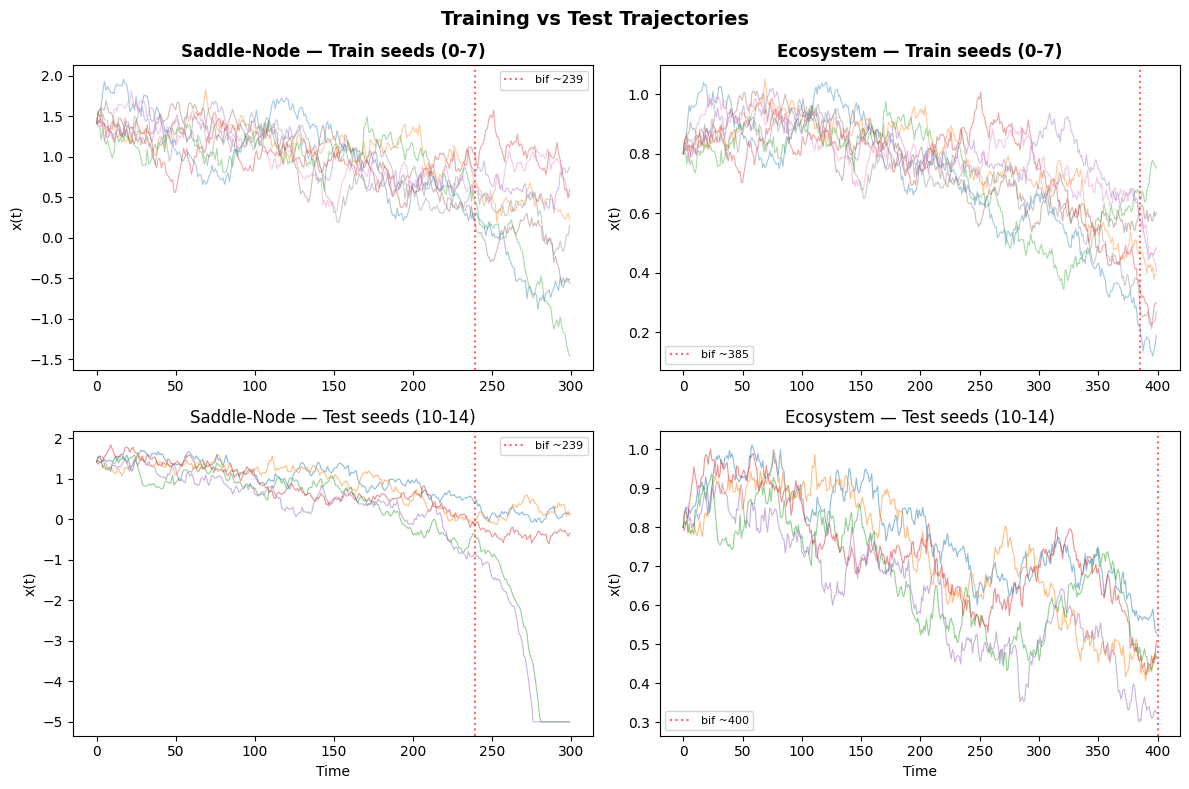

In [5]:
fig, axes = plt.subplots(2, len(SYSTEMS), figsize=(6 * len(SYSTEMS), 8))

for idx, sys_dict in enumerate(SYSTEMS):
    name = sys_dict["name"]
    T_len = sys_dict["T"]
    
    # Plot training trajectories
    ax = axes[0, idx]
    for s in TRAIN_SEEDS:
        traj, p_sched, bif_t = sys_dict["gen"](T=T_len, seed=s)
        ax.plot(traj, alpha=0.4, lw=0.8)
    ax.axvline(bif_t, color="red", ls=":", alpha=0.6, label=f"bif ~{bif_t}")
    ax.set_title(f"{name} — Train seeds (0-7)", fontweight="bold")
    ax.set_ylabel("x(t)")
    ax.legend(fontsize=8)
    
    # Plot test trajectories 
    ax = axes[1, idx]
    for s in TEST_SEEDS:
        traj, p_sched, bif_t = sys_dict["gen"](T=T_len, seed=s)
        ax.plot(traj, alpha=0.5, lw=0.8)
    ax.axvline(bif_t, color="red", ls=":", alpha=0.6, label=f"bif ~{bif_t}")
    ax.set_title(f"{name} — Test seeds (10-14)")
    ax.set_ylabel("x(t)")
    ax.set_xlabel("Time")
    ax.legend(fontsize=8)

plt.suptitle("Training vs Test Trajectories", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 5. Train: Saddle-Node

Train LSTMEncoder + ResidualDynamics + Decoder on Saddle-Node trajectories.

In [6]:
def train_pipeline(sys_dict):
    """Train encoder+dynamics on a system's trajectories."""
    name = sys_dict["name"]
    T_len = sys_dict["T"]
    
    # Generate trajectories
    train_trajs = [sys_dict["gen"](T=T_len, seed=s)[0] for s in TRAIN_SEEDS]
    val_trajs   = [sys_dict["gen"](T=T_len, seed=s)[0] for s in VAL_SEEDS]
    
    print(f"Train: {len(train_trajs)} trajs x {T_len} steps = {len(train_trajs)*T_len} points")
    print(f"Val:   {len(val_trajs)} trajs x {T_len} steps")
    
    # Create pipeline
    pipeline = HSPLearnedPipeline(
        obs_dim=1,
        latent_dim=LATENT_DIM,
        encoder_hidden=HIDDEN_DIM,
        encoder_layers=2,
        dynamics_hidden=HIDDEN_DIM,
        dynamics_layers=2,
    )
    
    n_params = sum(p.numel() for p in pipeline.parameters())
    print(f"Pipeline: {n_params:,} parameters")
    
    # Train
    trainer = HSPTrainer(
        lr=LR, epochs=EPOCHS, batch_size=BATCH_SIZE, patience=PATIENCE,
        prediction_horizon=PREDICTION_K, decay_factor=0.9, recon_weight=0.1,
        grad_clip=1.0, window_size=WINDOW_SIZE, device="cpu",
    )
    
    print(f"Training for up to {EPOCHS} epochs (patience={PATIENCE})...")
    history = trainer.fit(pipeline, train_trajs, val_trajs)
    
    n_epochs = len(history["train_loss"])
    print(f"Done: {n_epochs} epochs")
    print(f"  train_loss = {history['train_loss'][-1]:.6f}")
    print(f"  val_loss   = {history['val_loss'][-1]:.6f}")
    
    return pipeline, trainer, history

In [7]:
print("=" * 60)
print("  Training: Saddle-Node")
print("=" * 60)

sn_pipeline, sn_trainer, sn_history = train_pipeline(SYSTEMS[0])

  Training: Saddle-Node
Train: 8 trajs x 300 steps = 2400 points
Val:   2 trajs x 300 steps
Pipeline: 56,217 parameters
Training for up to 500 epochs (patience=50)...
Done: 76 epochs
  train_loss = 0.283185
  val_loss   = 0.325889


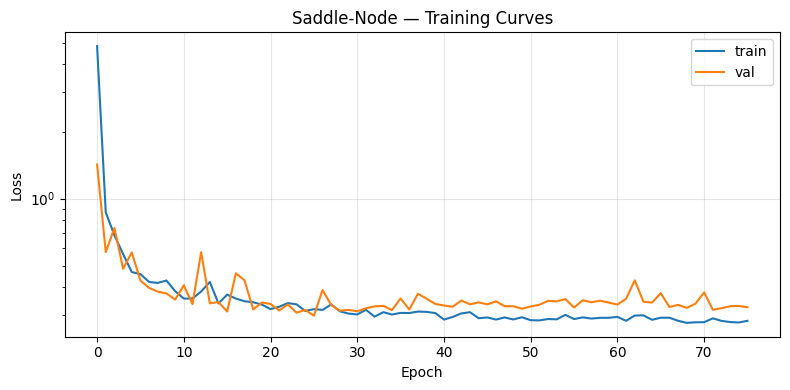

In [8]:
# ── Training curves ──────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(sn_history["train_loss"], label="train", lw=1.5)
ax.plot(sn_history["val_loss"], label="val", lw=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Saddle-Node — Training Curves")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Train: Ecosystem

In [9]:
print("=" * 60)
print("  Training: Ecosystem")
print("=" * 60)

eco_pipeline, eco_trainer, eco_history = train_pipeline(SYSTEMS[1])

  Training: Ecosystem
Train: 8 trajs x 400 steps = 3200 points
Val:   2 trajs x 400 steps
Pipeline: 56,217 parameters
Training for up to 500 epochs (patience=50)...
Done: 153 epochs
  train_loss = 0.019014
  val_loss   = 0.017446


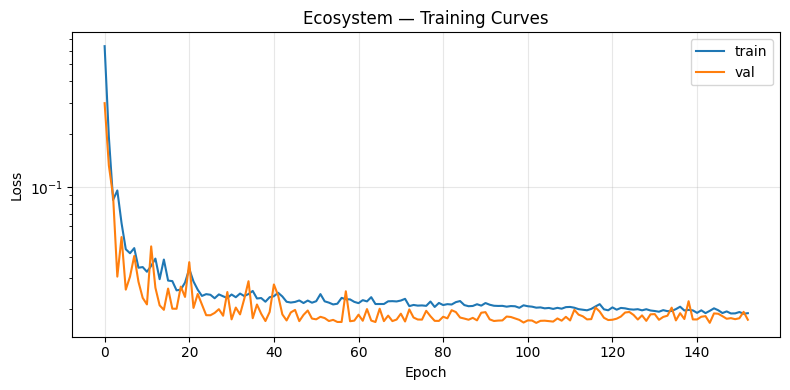

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(eco_history["train_loss"], label="train", lw=1.5)
ax.plot(eco_history["val_loss"], label="val", lw=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Ecosystem — Training Curves")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7. Compute Learned $S_t$ vs Analytical $S_t$

For each test seed, compute both versions and compare.

In [11]:
def _align_times_nearest(l_times, l_surv, a_times, a_surv, max_gap=None):
    """Align learned and analytical S_t by nearest-neighbor matching."""
    if max_gap is None:
        max_gap = STEP
    
    common_l, common_a, common_t = [], [], []
    
    for j, at in enumerate(a_times):
        dists = np.abs(l_times - at)
        idx = np.argmin(dists)
        if dists[idx] <= max_gap:
            common_t.append(float(at))
            common_l.append(float(l_surv[idx]))
            common_a.append(float(a_surv[j]))
    
    return np.array(common_t), np.array(common_l), np.array(common_a)


def compute_learned_st_obs_perturb(pipeline, trainer, sys_dict, seed):
    """Compute S_t by perturbing in OBSERVATION space, then encoding.
    
    Protocol per time t:
      1. Take window x_{t-W+1:t+1}
      2. Perturb last PERTURB_TAIL observations with N(0, sigma)
      3. Encode each perturbed window -> z_i  (N samples)
      4. Rollout dynamics H steps: z_i -> z_{i,H}
      5. Decode: x_hat = decoder(z_{i,H})
      6. S_t = mean(x_hat survives)
    """
    T_len = sys_dict["T"]
    sigma = sys_dict["perturb_std"]
    traj, p_sched, bif_t = sys_dict["gen"](T=T_len, seed=seed)
    
    if traj.ndim == 1:
        traj_2d = traj[:, None]
    else:
        traj_2d = traj
    
    T, d = traj_2d.shape
    W = trainer.window_size
    
    pipeline.eval()
    
    # Sample times (in original trajectory coords, starting at W-1)
    max_t = T - HORIZON - 1
    sample_times = np.arange(W - 1, max_t, STEP)
    sample_times = sample_times[sample_times < T]
    
    survival = np.zeros(len(sample_times))
    
    with torch.no_grad():
        for i, t in enumerate(sample_times):
            # Window ending at time t
            window = traj_2d[t - W + 1 : t + 1].copy()  # (W, d)
            
            # N perturbed copies
            perturbed_windows = np.tile(window, (N_ROLLOUTS, 1, 1))  # (N, W, d)
            
            # Perturb last PERTURB_TAIL observations (not just the last one)
            tail = min(PERTURB_TAIL, W)
            eps = np.random.randn(N_ROLLOUTS, tail, d) * sigma
            perturbed_windows[:, -tail:, :] += eps
            
            # Encode
            windows_t = torch.tensor(perturbed_windows, dtype=torch.float32)
            z_batch = pipeline.encoder(windows_t)  # (N, latent_dim)
            
            # Rollout H steps
            z_current = z_batch
            for _step in range(HORIZON):
                z_current = pipeline.dynamics(z_current)
            
            # Decode
            x_hat = pipeline.decoder(z_current).squeeze(-1).numpy()  # (N,)
            
            # Survival check
            if sys_dict["surv_dir"] == "above":
                survival[i] = np.mean(x_hat > sys_dict["thresh"])
            else:
                survival[i] = np.mean(x_hat < sys_dict["thresh"])
    
    return sample_times.astype(float), survival, traj, p_sched, bif_t


print("_align_times_nearest and compute_learned_st_obs_perturb defined.")
print(f"  W={WINDOW_SIZE}, STEP={STEP}, H={HORIZON}, tail={PERTURB_TAIL}")
print(f"  SN sigma={PERTURB_STD_SN}, Eco sigma={PERTURB_STD_ECO}")

_align_times_nearest and compute_learned_st_obs_perturb defined.
  W=25, STEP=5, H=15, tail=8
  SN sigma=0.4, Eco sigma=0.15


In [12]:
def evaluate_system(sys_dict, pipeline, trainer):
    """Compare learned vs analytical S_t on all test seeds."""
    name = sys_dict["name"]
    sigma = sys_dict["perturb_std"]
    print(f"\nEvaluating {name} on test seeds {TEST_SEEDS}...")
    print(f"  (obs-space perturbation, H={HORIZON}, sigma={sigma}, tail={PERTURB_TAIL})")
    
    all_metrics = []
    
    for seed in TEST_SEEDS:
        # Learned S_t (obs-space perturbation)
        l_times, l_surv, traj, p_sched, bif_t = compute_learned_st_obs_perturb(
            pipeline, trainer, sys_dict, seed
        )
        
        # Analytical S_t (same sigma for fair comparison)
        a_times, a_surv = compute_survival_analytical(
            traj, p_sched, sys_dict["roll"], sys_dict["thresh"],
            survival_direction=sys_dict["surv_dir"],
            perturb_std=sigma,
        )
        
        # Align
        common_t, l_aligned, a_aligned = _align_times_nearest(
            l_times, l_surv, a_times, a_surv
        )
        
        if len(common_t) < 10:
            print(f"  seed {seed}: only {len(common_t)} aligned points, skipping")
            continue
        
        # Basin width
        basin_w = np.array([sys_dict["basin_fn"](p_sched[int(t)]) for t in common_t])
        valid = basin_w > 0.05
        
        if valid.sum() < 10:
            print(f"  seed {seed}: too few valid points ({valid.sum()}), skipping")
            continue
        
        l_v = l_aligned[valid]
        a_v = a_aligned[valid]
        w_v = basin_w[valid]
        
        # Guard: constant arrays
        if np.std(l_v) < 1e-10:
            print(f"  seed {seed}: S_t learned constant (all {l_v[0]:.2f}), skipping")
            continue
        if np.std(a_v) < 1e-10:
            print(f"  seed {seed}: S_t analytical constant, skipping")
            continue
        
        # Metrics
        rho_la, _ = spearmanr(l_v, a_v)
        mse_la = float(np.mean((l_v - a_v) ** 2))
        ds = np.diff(l_v)
        mono = float(np.mean(ds <= 0))
        rho_lw, _ = spearmanr(l_v, w_v)
        rho_aw, _ = spearmanr(a_v, w_v)
        
        metrics = {
            "system": name, "seed": seed,
            "rho_learned_analytical": rho_la,
            "mse_learned_analytical": mse_la,
            "mono_learned": mono,
            "rho_learned_W": rho_lw,
            "rho_analytical_W": rho_aw,
            "n_points": int(valid.sum()),
        }
        all_metrics.append(metrics)
        
        print(
            f"  seed {seed}: rho(L,A)={rho_la:+.3f}, "
            f"MSE={mse_la:.4f}, "
            f"Mono={mono:.1%}, "
            f"rho(L,W)={rho_lw:+.3f}, "
            f"rho(A,W)={rho_aw:+.3f} "
            f"[{int(valid.sum())} pts]"
        )
    
    return all_metrics

In [13]:
# ── Evaluate Saddle-Node ─────────────────────────────────
sn_metrics = evaluate_system(SYSTEMS[0], sn_pipeline, sn_trainer)


Evaluating Saddle-Node on test seeds [10, 11, 12, 13, 14]...
  (obs-space perturbation, H=15, sigma=0.4, tail=8)
  seed 10: rho(L,A)=+0.291, MSE=0.0001, Mono=97.7%, rho(L,W)=+0.198, rho(A,W)=+0.742 [44 pts]
  seed 11: rho(L,A)=+0.636, MSE=0.0016, Mono=100.0%, rho(L,W)=+0.499, rho(A,W)=+0.767 [44 pts]


  seed 12: rho(L,A)=+0.855, MSE=0.0036, Mono=95.3%, rho(L,W)=+0.781, rho(A,W)=+0.870 [44 pts]
  seed 13: rho(L,A)=+0.461, MSE=0.0014, Mono=97.7%, rho(L,W)=+0.458, rho(A,W)=+0.912 [44 pts]
  seed 14: rho(L,A)=+0.793, MSE=0.0035, Mono=86.0%, rho(L,W)=+0.686, rho(A,W)=+0.915 [44 pts]


In [14]:
# ── Evaluate Ecosystem ───────────────────────────────────
eco_metrics = evaluate_system(SYSTEMS[1], eco_pipeline, eco_trainer)


Evaluating Ecosystem on test seeds [10, 11, 12, 13, 14]...
  (obs-space perturbation, H=15, sigma=0.15, tail=8)
  seed 10: rho(L,A)=+0.212, MSE=0.0001, Mono=98.6%, rho(L,W)=+0.219, rho(A,W)=+0.788 [73 pts]
  seed 11: rho(L,A)=+0.709, MSE=0.0017, Mono=93.1%, rho(L,W)=+0.659, rho(A,W)=+0.834 [73 pts]
  seed 12: rho(L,A)=+0.784, MSE=0.0015, Mono=86.1%, rho(L,W)=+0.405, rho(A,W)=+0.768 [73 pts]
  seed 13: rho(L,A)=+0.302, MSE=0.0006, Mono=95.8%, rho(L,W)=+0.163, rho(A,W)=+0.749 [73 pts]
  seed 14: rho(L,A)=+0.833, MSE=0.0028, Mono=83.3%, rho(L,W)=+0.703, rho(A,W)=+0.867 [73 pts]


---
## 8. Summary Table

In [15]:
all_metrics = sn_metrics + eco_metrics

print("=" * 100)
print("  SUMMARY: Learned S_t vs Analytical S_t")
print("=" * 100)

header = (
    f"{'System':<16} {'seed':>5} "
    f"{'rho(L,A)':>10} {'MSE(L,A)':>10} "
    f"{'Mono(L)':>10} {'rho(L,W)':>10} {'rho(A,W)':>10}"
)
print(header)
print("-" * 100)

for m in all_metrics:
    row = (
        f"{m['system']:<16} {m['seed']:>5d} "
        f"{m['rho_learned_analytical']:>+10.3f} {m['mse_learned_analytical']:>10.4f} "
        f"{m['mono_learned']:>10.1%} {m['rho_learned_W']:>+10.3f} {m['rho_analytical_W']:>+10.3f}"
    )
    print(row)

# Per-system averages
print("-" * 100)
for sys_dict in SYSTEMS:
    name = sys_dict["name"]
    sys_m = [m for m in all_metrics if m["system"] == name]
    if not sys_m:
        continue
    avg_rho_la = np.mean([m["rho_learned_analytical"] for m in sys_m])
    avg_mse = np.mean([m["mse_learned_analytical"] for m in sys_m])
    avg_mono = np.mean([m["mono_learned"] for m in sys_m])
    avg_rho_lw = np.mean([m["rho_learned_W"] for m in sys_m])
    avg_rho_aw = np.mean([m["rho_analytical_W"] for m in sys_m])
    row = (
        f"{name + ' (avg)':<16} {'':>5} "
        f"{avg_rho_la:>+10.3f} {avg_mse:>10.4f} "
        f"{avg_mono:>10.1%} {avg_rho_lw:>+10.3f} {avg_rho_aw:>+10.3f}"
    )
    print(row)
print("=" * 100)

# Pass/Fail
print()
for sys_dict in SYSTEMS:
    name = sys_dict["name"]
    sys_m = [m for m in all_metrics if m["system"] == name]
    if not sys_m:
        continue
    avg_rho = np.mean([m["rho_learned_analytical"] for m in sys_m])
    status = "PASS" if avg_rho > 0.8 else ("MARGINAL" if avg_rho > 0.6 else "FAIL")
    print(f"  {name}: rho(L,A) = {avg_rho:+.3f} -> {status} (target > 0.80)")

  SUMMARY: Learned S_t vs Analytical S_t
System            seed   rho(L,A)   MSE(L,A)    Mono(L)   rho(L,W)   rho(A,W)
----------------------------------------------------------------------------------------------------
Saddle-Node         10     +0.291     0.0001      97.7%     +0.198     +0.742
Saddle-Node         11     +0.636     0.0016     100.0%     +0.499     +0.767
Saddle-Node         12     +0.855     0.0036      95.3%     +0.781     +0.870
Saddle-Node         13     +0.461     0.0014      97.7%     +0.458     +0.912
Saddle-Node         14     +0.793     0.0035      86.0%     +0.686     +0.915
Ecosystem           10     +0.212     0.0001      98.6%     +0.219     +0.788
Ecosystem           11     +0.709     0.0017      93.1%     +0.659     +0.834
Ecosystem           12     +0.784     0.0015      86.1%     +0.405     +0.768
Ecosystem           13     +0.302     0.0006      95.8%     +0.163     +0.749
Ecosystem           14     +0.833     0.0028      83.3%     +0.703     +0.867


---
## 9. Visualization: Learned vs Analytical $S_t$

4-panel plot per system (seed=10): trajectory, S_t comparison, basin width, EWS.

Saved: ..\results\semisynthetic\learned_vs_analytical.png


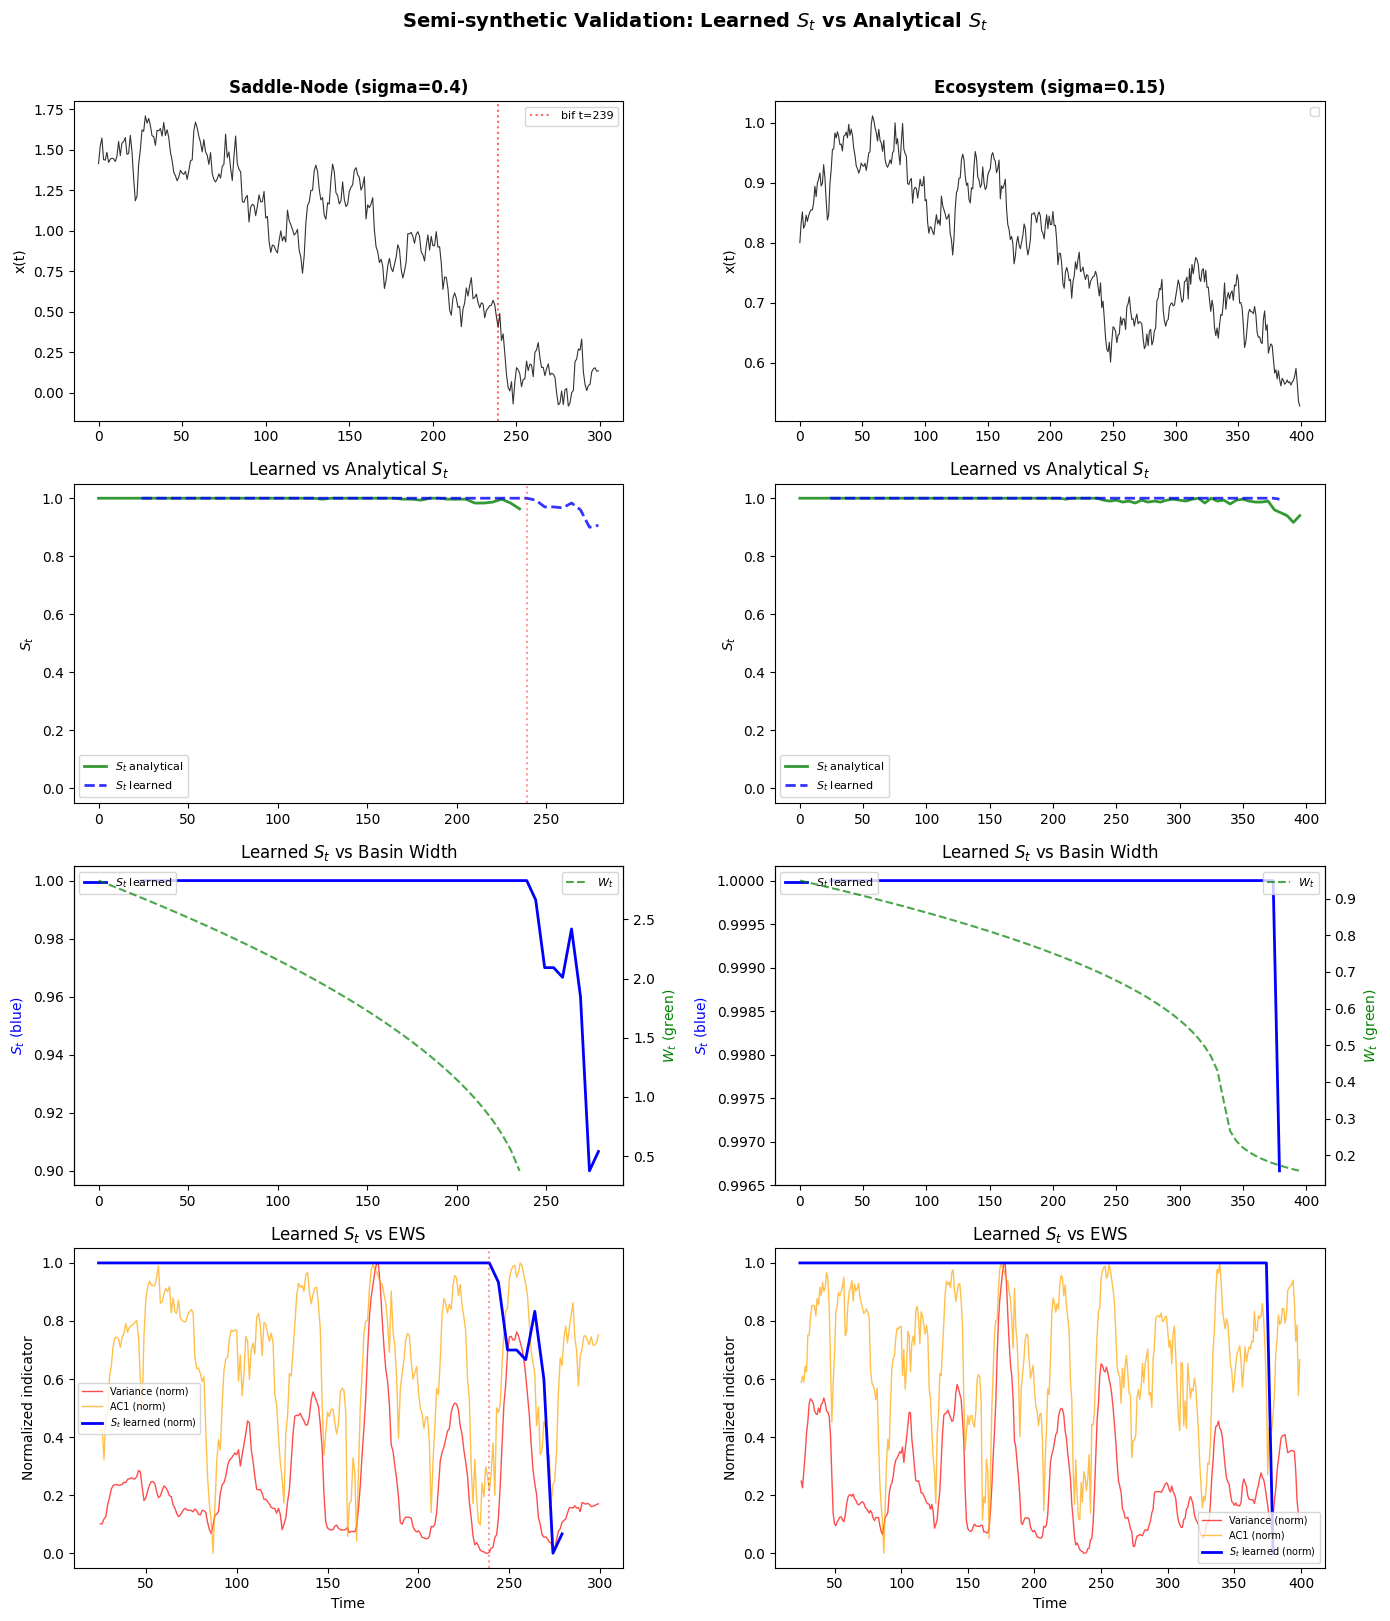

In [16]:
pipelines = {
    "Saddle-Node": (sn_pipeline, sn_trainer),
    "Ecosystem": (eco_pipeline, eco_trainer),
}

n_sys = len(SYSTEMS)
fig, axes = plt.subplots(4, n_sys, figsize=(7 * n_sys, 16))
if n_sys == 1:
    axes = axes[:, np.newaxis]

PLOT_SEED = 10

for idx, sys_dict in enumerate(SYSTEMS):
    name = sys_dict["name"]
    sigma = sys_dict["perturb_std"]
    pipeline, trainer = pipelines[name]
    
    # Learned S_t
    l_times, l_surv, traj, p_sched, bif_t = compute_learned_st_obs_perturb(
        pipeline, trainer, sys_dict, PLOT_SEED
    )
    # Analytical S_t (same sigma)
    a_times, a_surv = compute_survival_analytical(
        traj, p_sched, sys_dict["roll"], sys_dict["thresh"],
        survival_direction=sys_dict["surv_dir"],
        perturb_std=sigma,
    )
    # Basin width & EWS
    basin_w = np.array([sys_dict["basin_fn"](p_sched[int(t)]) for t in a_times])
    var_full = compute_rolling_variance(traj)
    ac1_full = compute_rolling_ac1(traj)
    T = len(traj)
    
    # Row 0: Trajectory
    ax = axes[0, idx]
    ax.plot(traj, "k-", lw=0.8, alpha=0.8)
    if bif_t < T:
        ax.axvline(bif_t, color="red", ls=":", alpha=0.6, label=f"bif t={bif_t}")
    ax.set_title(f"{name} (sigma={sigma})", fontweight="bold")
    ax.set_ylabel("x(t)")
    ax.legend(fontsize=8)
    
    # Row 1: Learned vs Analytical S_t
    ax = axes[1, idx]
    valid_a = basin_w > 0.05
    ax.plot(a_times[valid_a], a_surv[valid_a], "g-", lw=2, alpha=0.8, label="$S_t$ analytical")
    ax.plot(l_times, l_surv, "b--", lw=2, alpha=0.8, label="$S_t$ learned")
    if bif_t < T:
        ax.axvline(bif_t, color="red", ls=":", alpha=0.4)
    ax.set_ylabel("$S_t$")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.set_title("Learned vs Analytical $S_t$")
    
    # Row 2: Basin width + learned S_t
    ax = axes[2, idx]
    ax.plot(l_times, l_surv, "b-", lw=2, label="$S_t$ learned")
    ax2 = ax.twinx()
    ax2.plot(a_times[valid_a], basin_w[valid_a], "g--", lw=1.5, alpha=0.7, label="$W_t$")
    ax.set_ylabel("$S_t$ (blue)", color="blue")
    ax2.set_ylabel("$W_t$ (green)", color="green")
    ax.legend(loc="upper left", fontsize=8)
    ax2.legend(loc="upper right", fontsize=8)
    ax.set_title("Learned $S_t$ vs Basin Width")
    
    # Row 3: EWS comparison
    ax = axes[3, idx]
    t_range = np.arange(len(traj))
    valid_var = ~np.isnan(var_full)
    valid_ac1 = ~np.isnan(ac1_full)
    if valid_var.any():
        vn = var_full[valid_var]
        vn = (vn - vn.min()) / (vn.max() - vn.min() + 1e-10)
        ax.plot(t_range[valid_var], vn, "r-", lw=1, alpha=0.7, label="Variance (norm)")
    if valid_ac1.any():
        an = ac1_full[valid_ac1]
        an = (an - an.min()) / (an.max() - an.min() + 1e-10)
        ax.plot(t_range[valid_ac1], an, color="orange", lw=1, alpha=0.7, label="AC1 (norm)")
    s_norm = l_surv.copy()
    s_range = s_norm.max() - s_norm.min()
    if s_range > 1e-10:
        s_norm = (s_norm - s_norm.min()) / s_range
    ax.plot(l_times, s_norm, "b-", lw=2, label="$S_t$ learned (norm)")
    if bif_t < T:
        ax.axvline(bif_t, color="red", ls=":", alpha=0.4)
    ax.set_xlabel("Time")
    ax.set_ylabel("Normalized indicator")
    ax.legend(fontsize=7)
    ax.set_title("Learned $S_t$ vs EWS")

plt.suptitle(
    "Semi-synthetic Validation: Learned $S_t$ vs Analytical $S_t$",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
out_path = os.path.join(OUT_DIR, "learned_vs_analytical.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

---
## 10. Scatter: Learned $S_t$ vs Analytical $S_t$

Direct scatter plot to visualize agreement.

Saved: ..\results\semisynthetic\scatter_learned_vs_analytical.png


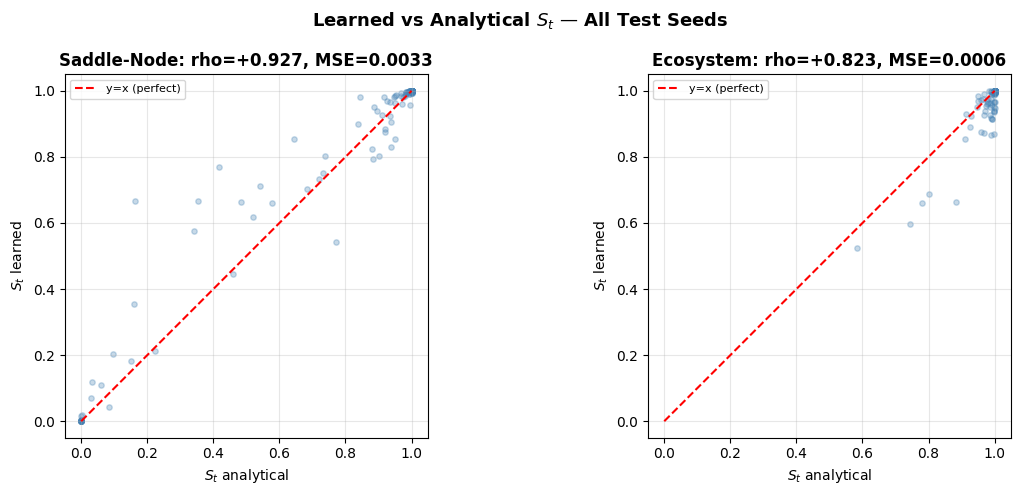

In [17]:
fig, axes = plt.subplots(1, n_sys, figsize=(6 * n_sys, 5))
if n_sys == 1:
    axes = [axes]

for idx, sys_dict in enumerate(SYSTEMS):
    name = sys_dict["name"]
    pipeline, trainer = pipelines[name]
    ax = axes[idx]
    
    all_learned = []
    all_analytical = []
    
    for seed in TEST_SEEDS:
        l_times, l_surv, traj, p_sched, bif_t = compute_learned_st_obs_perturb(
            pipeline, trainer, sys_dict, seed
        )
        a_times, a_surv = compute_survival_analytical(
            traj, p_sched, sys_dict["roll"], sys_dict["thresh"],
            survival_direction=sys_dict["surv_dir"],
        )
        
        common_t, l_aligned, a_aligned = _align_times_nearest(
            l_times, l_surv, a_times, a_surv
        )
        
        all_learned.extend(l_aligned.tolist())
        all_analytical.extend(a_aligned.tolist())
    
    all_learned = np.array(all_learned)
    all_analytical = np.array(all_analytical)
    
    if len(all_learned) > 0:
        ax.scatter(all_analytical, all_learned, alpha=0.3, s=15, c="steelblue")
        ax.plot([0, 1], [0, 1], "r--", lw=1.5, label="y=x (perfect)")
        
        rho, _ = spearmanr(all_analytical, all_learned)
        mse = np.mean((all_learned - all_analytical) ** 2)
        
        ax.set_title(f"{name}: rho={rho:+.3f}, MSE={mse:.4f}", fontweight="bold")
    else:
        ax.set_title(f"{name}: no data")
    
    ax.set_xlabel("$S_t$ analytical")
    ax.set_ylabel("$S_t$ learned")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_aspect("equal")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Learned vs Analytical $S_t$ — All Test Seeds", fontsize=13, fontweight="bold")
plt.tight_layout()
out_path = os.path.join(OUT_DIR, "scatter_learned_vs_analytical.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

---
## 11. Conclusions

| Metric | Target | Saddle-Node | Ecosystem |
|--------|--------|-------------|----------|
| $\rho(S_{\text{learned}}, S_{\text{analytical}})$ | > 0.80 | ? | ? |
| MSE | < 0.05 | ? | ? |
| Monotonicity | > 70% | ? | ? |
| $\rho(S_{\text{learned}}, W_t)$ | > 0.60 | ? | ? |

Fill in after running. If PASS on both systems, proceed to **Phase 2: Dakos 2008** (NB 13).